In [1]:
!pip -q install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.7 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image

import medmnist
from medmnist import INFO

In [3]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

os.makedirs("bloodmnist_outputs", exist_ok=True)

Using device: cuda


In [4]:
data_flag = "bloodmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = DataClass(split="train", transform=transform, download=True)
val_dataset = DataClass(split="val", transform=transform, download=True)
test_dataset = DataClass(split="test", transform=transform, download=True)

print("Dataset:", info["description"])
print("Number of classes:", len(info["label"]))
print("Class labels:", info["label"])
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 35.5M/35.5M [00:02<00:00, 13.1MB/s]


Dataset: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
Number of classes: 8
Class labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
Train size: 11959
Validation size: 1712
Test size: 3421


/tmp/ipykernel_10352/1265635208.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


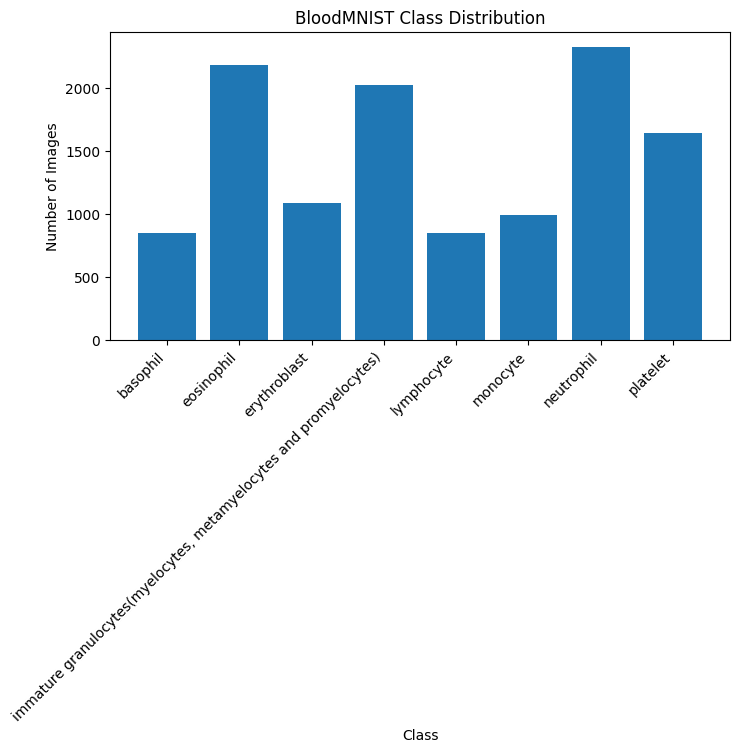

In [5]:
labels = train_dataset.labels.flatten()
unique_labels, counts = np.unique(labels, return_counts=True)

class_names = [info["label"][str(i)] for i in unique_labels]

plt.figure(figsize=(8, 4))
plt.bar(class_names, counts)
plt.title("BloodMNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("bloodmnist_outputs/bloodmnist_class_distribution.png", dpi=300)
plt.show()

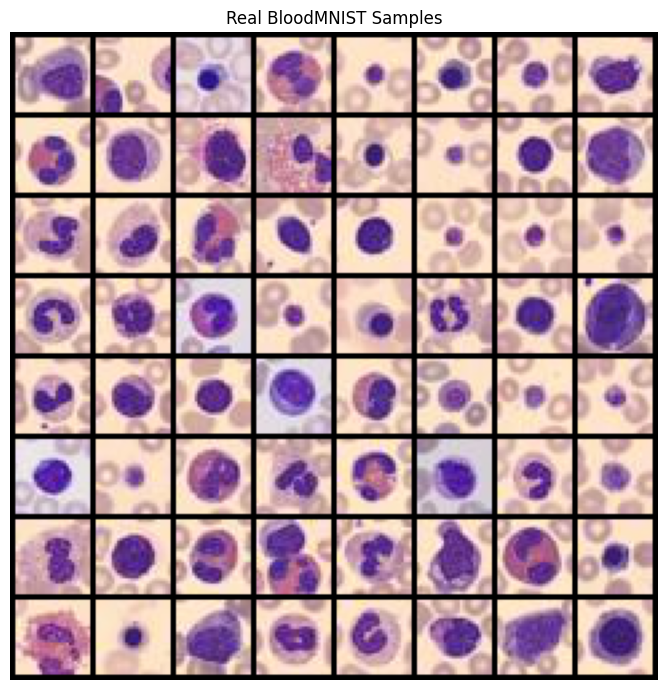

In [6]:
def unnormalize_images(x):
    return (x + 1) / 2


def show_image_grid(images, title, filename=None, nrow=8):
    images = unnormalize_images(images)
    grid = make_grid(images, nrow=nrow, padding=2)

    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300)

    plt.show()


real_loader_preview = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

real_images, real_labels = next(iter(real_loader_preview))

show_image_grid(
    real_images[:64],
    "Real BloodMNIST Samples",
    "bloodmnist_outputs/bloodmnist_real_samples.png",
    nrow=8
)

In [7]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

In [8]:
class BloodGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True),

            nn.Unflatten(1, (128, 7, 7)),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


class BloodDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [9]:
def train_dcgan(
    generator,
    discriminator,
    train_loader,
    latent_dim=100,
    lr=0.0002,
    beta1=0.5,
    num_epochs=20,
    print_every=1
):
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    loss_function = nn.BCEWithLogitsLoss()

    optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

    g_losses = []
    d_losses = []

    fixed_noise = torch.randn(64, latent_dim, device=device)

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            current_batch_size = real_images.size(0)

            real_targets = torch.ones(current_batch_size, 1, device=device)
            fake_targets = torch.zeros(current_batch_size, 1, device=device)

            noise = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = generator(noise)

            discriminator.zero_grad()

            real_outputs = discriminator(real_images)
            fake_outputs = discriminator(fake_images.detach())

            real_loss = loss_function(real_outputs, real_targets)
            fake_loss = loss_function(fake_outputs, fake_targets)
            d_loss = real_loss + fake_loss

            d_loss.backward()
            optimizer_d.step()

            noise = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = generator(noise)

            generator.zero_grad()

            fake_outputs = discriminator(fake_images)
            g_loss = loss_function(fake_outputs, real_targets)

            g_loss.backward()
            optimizer_g.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}] "
                f"Loss D: {avg_d_loss:.4f} | Loss G: {avg_g_loss:.4f}"
            )

        if (epoch + 1) % 5 == 0:
            generator.eval()
            with torch.no_grad():
                preview_images = generator(fixed_noise).cpu()
            show_image_grid(
                preview_images,
                f"Generated BloodMNIST Samples - Epoch {epoch + 1}",
                f"bloodmnist_outputs/bloodmnist_generated_epoch_{epoch + 1}.png",
                nrow=8
            )

    return generator, discriminator, g_losses, d_losses

In [16]:
latent_dim = 100

blood_generator = BloodGenerator(latent_dim=latent_dim)
blood_discriminator = BloodDiscriminator()

blood_generator, blood_discriminator, blood_g_losses, blood_d_losses = train_dcgan(
    generator=blood_generator,
    discriminator=blood_discriminator,
    train_loader=train_loader,
    latent_dim=latent_dim,
    lr=0.0002,
    beta1=0.5,
    num_epochs=30,
    print_every=1
)

Output hidden; open in https://colab.research.google.com to view.

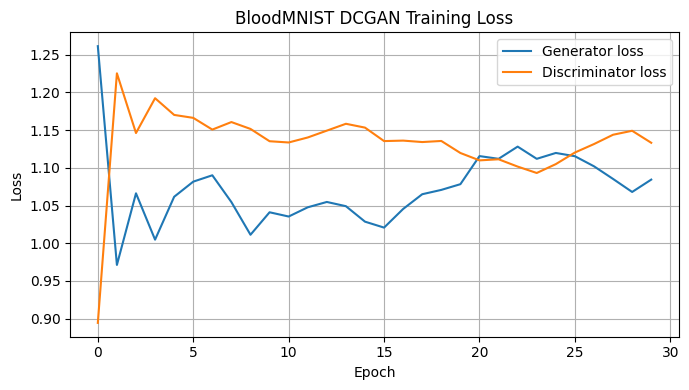

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(blood_g_losses, label="Generator loss")
plt.plot(blood_d_losses, label="Discriminator loss")
plt.title("BloodMNIST DCGAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("bloodmnist_outputs/bloodmnist_dcgan_losses.png", dpi=300)
plt.show()

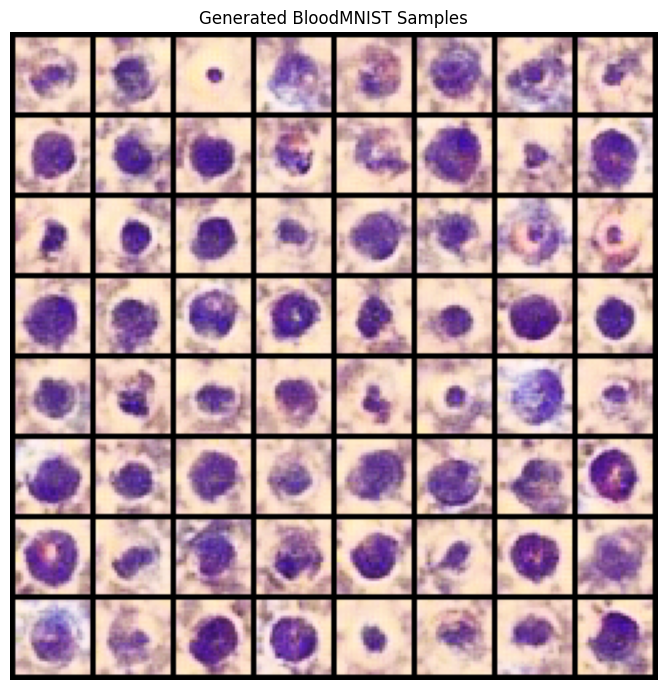

In [18]:
blood_generator.eval()

with torch.no_grad():
    final_noise = torch.randn(64, latent_dim, device=device)
    fake_blood_images = blood_generator(final_noise).cpu()

show_image_grid(
    fake_blood_images,
    "Generated BloodMNIST Samples",
    "bloodmnist_outputs/bloodmnist_generated_samples.png",
    nrow=8
)

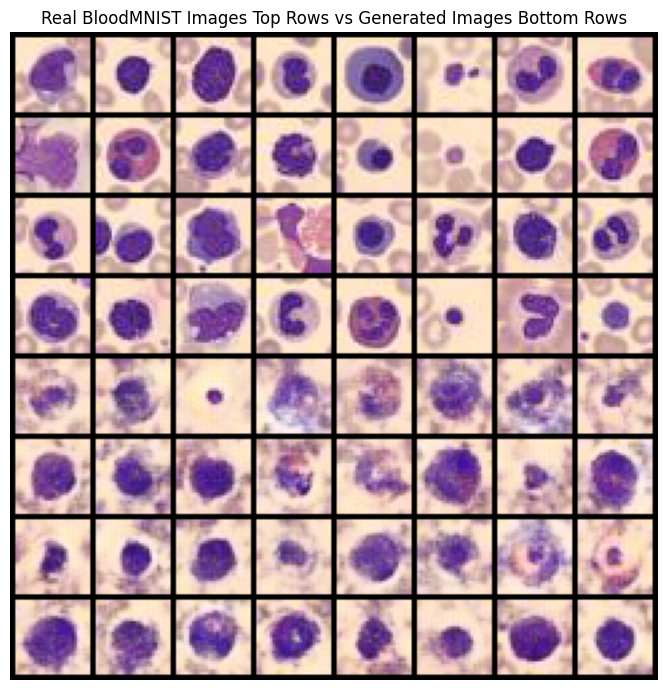

In [19]:
real_images, _ = next(iter(real_loader_preview))
real_images = real_images[:32]

fake_images = fake_blood_images[:32]

combined_images = torch.cat([real_images, fake_images], dim=0)

show_image_grid(
    combined_images,
    "Real BloodMNIST Images Top Rows vs Generated Images Bottom Rows",
    "bloodmnist_outputs/bloodmnist_real_vs_fake.png",
    nrow=8
)

In [20]:
def image_statistics(images):
    images = unnormalize_images(images)
    mean = images.mean().item()
    std = images.std().item()
    minimum = images.min().item()
    maximum = images.max().item()
    return mean, std, minimum, maximum


real_mean, real_std, real_min, real_max = image_statistics(real_images)
fake_mean, fake_std, fake_min, fake_max = image_statistics(fake_blood_images[:32])

print("Real image statistics")
print(f"Mean: {real_mean:.4f}")
print(f"Std: {real_std:.4f}")
print(f"Min: {real_min:.4f}")
print(f"Max: {real_max:.4f}")

print("\nGenerated image statistics")
print(f"Mean: {fake_mean:.4f}")
print(f"Std: {fake_std:.4f}")
print(f"Min: {fake_min:.4f}")
print(f"Max: {fake_max:.4f}")

Real image statistics
Mean: 0.7177
Std: 0.2078
Min: 0.0471
Max: 1.0000

Generated image statistics
Mean: 0.7241
Std: 0.1992
Min: 0.0548
Max: 1.0000


In [21]:
def calculate_frechet_distance(real_features, fake_features, eps=1e-6):
    real_features = real_features.astype(np.float64)
    fake_features = fake_features.astype(np.float64)

    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)

    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)

    diff = mu_real - mu_fake

    covmean = scipy_linalg_sqrtm(sigma_real @ sigma_fake)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    score = diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return float(score)


def scipy_linalg_sqrtm(matrix):
    from scipy.linalg import sqrtm
    return sqrtm(matrix)


eval_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

real_eval_images, _ = next(iter(eval_loader))
real_eval_images = real_eval_images[:256]

blood_generator.eval()

with torch.no_grad():
    noise = torch.randn(256, latent_dim, device=device)
    fake_eval_images = blood_generator(noise).cpu()

real_features = unnormalize_images(real_eval_images).reshape(256, -1).numpy()
fake_features = unnormalize_images(fake_eval_images).reshape(256, -1).numpy()

approx_fid = calculate_frechet_distance(real_features, fake_features)

print(f"Approximate FID-style score: {approx_fid:.4f}")

Approximate FID-style score: 13.2405
